### **Lung Cancer Detection Using CT Scan Image Segmentation and Classification using Image Processing.**

#### **Dataset Download**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d adityamahimkar/iqothnccd-lung-cancer-dataset

Dataset URL: https://www.kaggle.com/datasets/adityamahimkar/iqothnccd-lung-cancer-dataset
License(s): copyright-authors
100% 199M/199M [00:01<00:00, 131MB/s]



In [5]:
!unzip -q iqothnccd-lung-cancer-dataset.zip

#### Importing Libraries

In [6]:
import os
import shutil
import numpy as np
import pandas as pd
import random
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## **Organizing Dataset**

In [7]:
os.makedirs("dataset", exist_ok=True)

In [8]:
src_path = "The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"
dst_path = "dataset"
for i in os.listdir(src_path):
    os.rename(os.path.join(src_path, i), os.path.join(dst_path, i))

In [9]:
shutil.rmtree(src_path)
shutil.rmtree("The IQ-OTHNCCD lung cancer dataset")
shutil.rmtree("Test cases")
os.remove("dataset/IQ-OTH_NCCD lung cancer dataset.txt")

In [10]:
print(f"Images in Bengin cases are {len(os.listdir("dataset/Bengin cases"))}")
print(f"Images in Bengin cases are {len(os.listdir("dataset/Malignant cases"))}")
print(f"Images in Bengin cases are {len(os.listdir("dataset/Normal cases"))}")

Images in Bengin cases are 120
Images in Bengin cases are 561
Images in Bengin cases are 416


#### Splitting Dataset into Train Test Validation

In [11]:
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split

# Define paths
# These variables were previously deleted but are needed for the rest of the notebook.
# Re-defining them here to ensure continuity.
data_path = 'Data'
train_data_path = os.path.join(data_path, 'train')
test_data_path = os.path.join(data_path, 'test')
valid_data_path = os.path.join(data_path, 'valid')

base_original_dataset_path = "dataset"

# Create necessary directories for the final split
os.makedirs(train_data_path, exist_ok=True)
os.makedirs(test_data_path, exist_ok=True)
os.makedirs(valid_data_path, exist_ok=True)

# 1. Augment 'Bengin cases' in its original directory if needed
bengin_cases_original_path = os.path.join(base_original_dataset_path, "Bengin cases")
current_bengin_count = len(os.listdir(bengin_cases_original_path))
target_bengin_augmentation_count = 450
needed_bengin_augmentation = target_bengin_augmentation_count - current_bengin_count

print(f"Initial Bengin cases count: {current_bengin_count}")

if needed_bengin_augmentation > 0:
    print(f"Augmenting Bengin cases by {needed_bengin_augmentation} images...")
    # Initialize ImageDataGenerator for augmentation with parameters similar to the existing notebook's datagen
    datagen = ImageDataGenerator(
        rotation_range=25,
        width_shift_range=0.15,
        height_shift_range=0.15,
        shear_range=0.15,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    images_to_augment = os.listdir(bengin_cases_original_path)
    generated_count = 0

    # Loop through existing images to generate augmented ones
    for img_name in images_to_augment:
        if generated_count >= needed_bengin_augmentation:
            break

        img_path = os.path.join(bengin_cases_original_path, img_name)
        img = load_img(img_path)
        img = img_to_array(img)
        img = np.expand_dims(img, axis=0) # Reshape to (1, height, width, channels)

        # Flow images for augmentation and save generated images back to the same directory
        aug_iter = datagen.flow(
            img,
            batch_size=1,
            save_to_dir=bengin_cases_original_path,
            save_prefix="aug_bengin",
            save_format="jpg"
        )

        # Generate only the remaining needed images
        for _ in range(needed_bengin_augmentation - generated_count):
            next(aug_iter)
            generated_count += 1
            if generated_count >= needed_bengin_augmentation:
                break
    print(f"Augmentation finished. Generated {generated_count} additional Bengin cases.")
else:
    print("No augmentation needed for Bengin cases.")

current_bengin_count_after_augmentation = len(os.listdir(bengin_cases_original_path))
print(f"Bengin cases count after augmentation: {current_bengin_count_after_augmentation}")

# 2. Split dataset into Train, Test, Validation folders
all_classes_in_dataset = os.listdir(base_original_dataset_path)

for class_name in all_classes_in_dataset:
    class_src_path = os.path.join(base_original_dataset_path, class_name)
    if not os.path.isdir(class_src_path):
        continue

    images = os.listdir(class_src_path)
    # Filter to ensure only image files are considered for splitting
    image_files = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Create class-specific subdirectories in train, test, valid
    os.makedirs(os.path.join(train_data_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_data_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(valid_data_path, class_name), exist_ok=True)

    # Split data: 70% train, 15% test, 15% validation
    train_files, temp_files = train_test_split(image_files, test_size=0.3, random_state=42)
    test_files, val_files = train_test_split(temp_files, test_size=0.5, random_state=42) # 0.5 of the 30% is 15%

    # Copy files to their respective directories
    for img_file in train_files:
        shutil.copy(os.path.join(class_src_path, img_file), os.path.join(train_data_path, class_name, img_file))
    for img_file in test_files:
        shutil.copy(os.path.join(class_src_path, img_file), os.path.join(test_data_path, class_name, img_file))
    for img_file in val_files:
        shutil.copy(os.path.join(class_src_path, img_file), os.path.join(valid_data_path, class_name, img_file))

    print(f"Class '{class_name}': Split into Train: {len(train_files)}, Test: {len(test_files)}, Validation: {len(val_files)}")

print("\nDataset splitting and organization complete.")

# Verify counts in the new Data folders
print("\nVerifying counts in new Data folders:")
for split_path, split_name in [(train_data_path, "Train"), (test_data_path, "Test"), (valid_data_path, "Validation")]:
    print(f"\n{split_name} counts:")
    for class_name in os.listdir(split_path):
        if os.path.isdir(os.path.join(split_path, class_name)):
            print(f"  {class_name}: {len(os.listdir(os.path.join(split_path, class_name)))} images")

Initial Bengin cases count: 120
Augmenting Bengin cases by 330 images...
Augmentation finished. Generated 330 additional Bengin cases.
Bengin cases count after augmentation: 446
Class 'Normal cases': Split into Train: 291, Test: 62, Validation: 63
Class 'Malignant cases': Split into Train: 392, Test: 84, Validation: 85
Class 'Bengin cases': Split into Train: 312, Test: 67, Validation: 67

Dataset splitting and organization complete.

Verifying counts in new Data folders:

Train counts:
  Normal cases: 291 images
  Malignant cases: 392 images
  Bengin cases: 312 images

Test counts:
  Normal cases: 62 images
  Malignant cases: 84 images
  Bengin cases: 67 images

Validation counts:
  Normal cases: 63 images
  Malignant cases: 85 images
  Bengin cases: 67 images


#### **Sample Data**

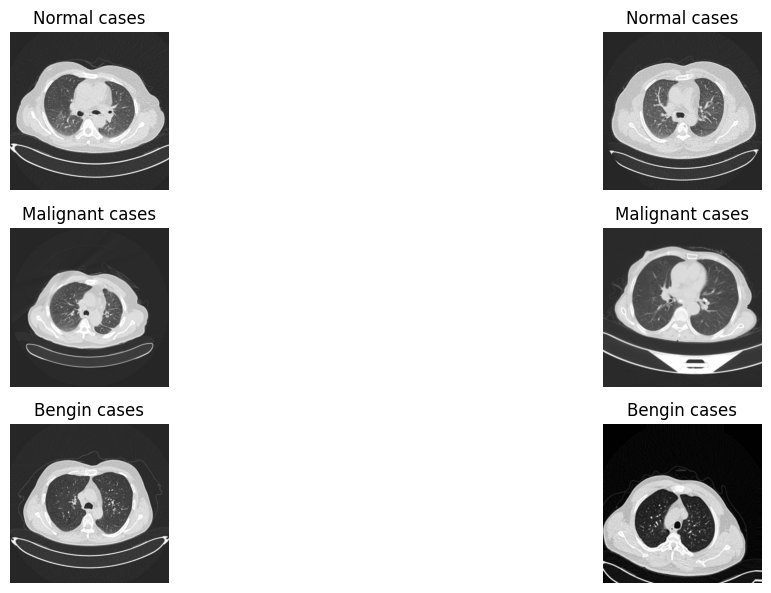

In [12]:
# Base directory
base_dir = train_data_path

classes = os.listdir(base_dir)

plt.figure(figsize=(12, 8))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(base_dir, class_name)

    # Randomly pick 2 images
    images = random.sample(os.listdir(class_path), 2)

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(4, 2, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

**Train Data Count**

In [13]:
for c in os.listdir(train_data_path):
    print(f"Count of Images in each class are {len(os.listdir(os.path.join(train_data_path, c)))}")

Count of Images in each class are 291
Count of Images in each class are 392
Count of Images in each class are 312


**Test Data Count**

In [14]:
for c in os.listdir(test_data_path):
    print(f"Count of Images in each class are {len(os.listdir(os.path.join(test_data_path, c)))}")

Count of Images in each class are 62
Count of Images in each class are 84
Count of Images in each class are 67


**Validation Data Count**

In [15]:
for c in os.listdir(valid_data_path):
    print(f"Count of Images in each class are {len(os.listdir(os.path.join(valid_data_path, c)))}")

Count of Images in each class are 63
Count of Images in each class are 85
Count of Images in each class are 67


#### Data Augmentation

In [16]:
image_dims = (224, 224)
batch_size = 16

# Train Data Augmentation
train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create the generators
train_generator = train_data.flow_from_directory(
    directory=train_data_path,
    target_size=image_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    directory=valid_data_path,
    target_size=image_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    directory=test_data_path,
    target_size=image_dims,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 995 images belonging to 3 classes.
Found 215 images belonging to 3 classes.
Found 213 images belonging to 3 classes.


In [17]:
train_generator.class_indices

{'Bengin cases': 0, 'Malignant cases': 1, 'Normal cases': 2}

## **Imbalance Check**

In [18]:
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

print("\nClass Distribution:")
for class_name, idx in class_labels.items():
    print(f"{class_name}: {counts[idx]}")

# Imbalance Ratio
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Labels: {'Bengin cases': 0, 'Malignant cases': 1, 'Normal cases': 2}

Class Distribution:
Bengin cases: 312
Malignant cases: 392
Normal cases: 291

Imbalance Ratio: 1.35


**As Imbalance Ratio is >1 so we need Balancing**

In [19]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(1.063034188034188), 1: np.float64(0.8460884353741497), 2: np.float64(1.1397479954180985)}


## **Model Building**

In [20]:
os.makedirs("models", exist_ok=True)

In [21]:
allresults = []
epochs = 20

### **MobileNetV2**

In [22]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [26]:
model_path = "models/mobilenet_model.keras"

In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
callbacks_list = [checkpoint, early_stopping]

In [28]:
# Load MobileNetV2 without the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_dims[0], image_dims[1], 3))

# Freeze the base model
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

# Final model
mobilenet_model = Model(inputs=base_model.input, outputs=predictions)

In [29]:
from tensorflow.keras.optimizers import Adam
mobilenet_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [30]:
mobilenet_history = mobilenet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks_list)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.2861 - loss: 1.7536
Epoch 1: val_accuracy improved from None to 0.30698, saving model to models/mobilenet_model.keras

Epoch 1: finished saving model to models/mobilenet_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 62s 701ms/step - accuracy: 0.2874 - loss: 1.5465 - val_accuracy: 0.3070 - val_loss: 1.2402
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.3785 - loss: 1.2105
Epoch 2: val_accuracy improved from 0.30698 to 0.51163, saving model to models/mobilenet_model.keras

Epoch 2: finished saving model to models/mobilenet_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.4191 - loss: 1.1525 - val_accuracy: 0.5116 - val_loss: 1.0118
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.5280 - loss: 1.0044
Epoch 3: val_accuracy improved from 0.51163 to 0.61860, saving model to models/mobilenet_model.keras

Epoch 3: finished saving model to models/mobilenet_model.keras
63/63 ━━━━━━━━

In [31]:
# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

mobilenet_model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.7420 - loss: 0.6193
Epoch 1: val_accuracy did not improve from 0.84651
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 466ms/step - accuracy: 0.8010 - loss: 0.5232 - val_accuracy: 0.8372 - val_loss: 0.4278
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.8631 - loss: 0.3932
Epoch 2: val_accuracy did not improve from 0.84651
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 0.8633 - loss: 0.3876 - val_accuracy: 0.8326 - val_loss: 0.4258
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.8810 - loss: 0.3228
Epoch 3: val_accuracy did not improve from 0.84651
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.8693 - loss: 0.3532 - val_accuracy: 0.8372 - val_loss: 0.4055
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8759 - loss: 0.3067
Epoch 4: val_accuracy did not improve from 0.84651
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 231ms/step - accuracy: 0.8774 - loss: 0.3066 - val_accuracy: 0.8419

**Test Accuracy**

In [32]:
mobilenet_test_loss, mobilenet_test_accuracy = mobilenet_model.evaluate(test_generator)
print(f"Test Accuracy: {mobilenet_test_accuracy * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 862ms/step - accuracy: 0.8826 - loss: 0.3531
Test Accuracy: 88.26%


**Accuracy Plot**

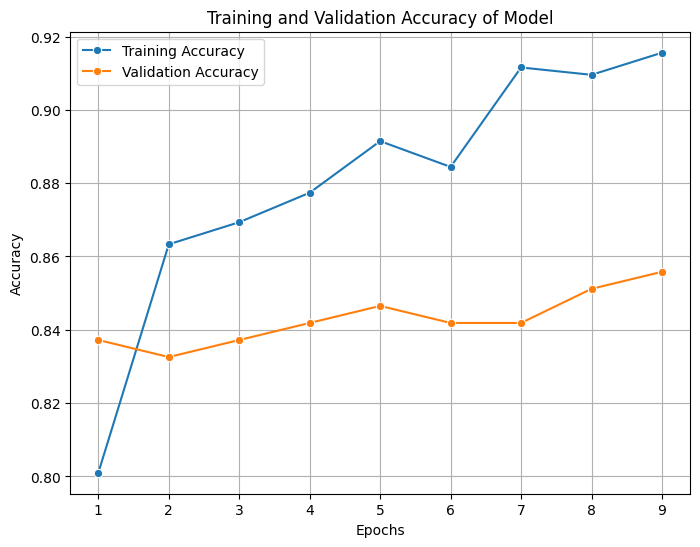

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare DataFrame from Keras history
df = pd.DataFrame({
    "Epoch": range(1, len(mobilenet_history.history['accuracy']) + 1),
    "Training Accuracy": mobilenet_history.history['accuracy'],
    "Validation Accuracy": mobilenet_history.history['val_accuracy']
})

# Melt DataFrame for Seaborn
df_melted = df.melt(id_vars="Epoch",
                   value_vars=["Training Accuracy", "Validation Accuracy"],
                   var_name="Type",
                   value_name="Accuracy")

plt.figure(figsize=(8,6))
sns.lineplot(data=df_melted, x="Epoch", y="Accuracy", hue="Type", marker="o")
plt.title('Training and Validation Accuracy of Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(title="")
plt.show()

**Loss Plot**

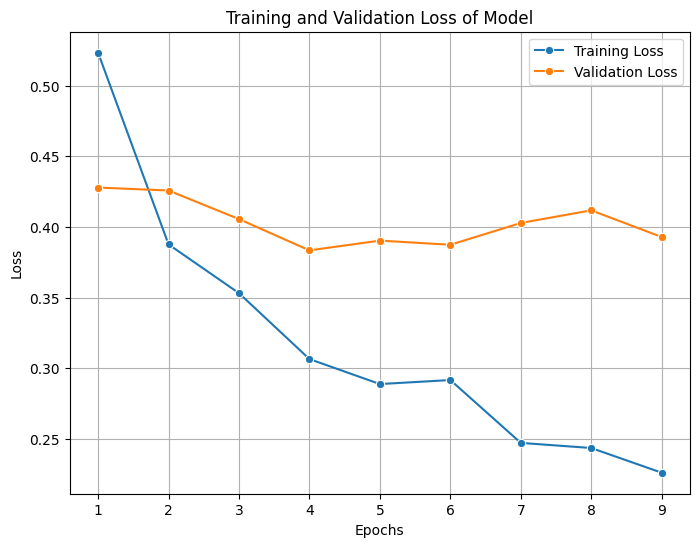

In [34]:
# Prepare DataFrame from Keras history for loss
df_loss = pd.DataFrame({
    "Epoch": range(1, len(mobilenet_history.history['loss']) + 1),
    "Training Loss": mobilenet_history.history['loss'],
    "Validation Loss": mobilenet_history.history['val_loss']
})

# Melt DataFrame for Seaborn
df_loss_melted = df_loss.melt(id_vars="Epoch",
                              value_vars=["Training Loss", "Validation Loss"],
                              var_name="Type",
                              value_name="Loss")

# Plot loss
plt.figure(figsize=(8,6))
sns.lineplot(data=df_loss_melted, x="Epoch", y="Loss", hue="Type", marker="o")
plt.title('Training and Validation Loss of Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(title="")
plt.show()

In [35]:
# Predict on test set
mob_y_pred = mobilenet_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
mob_y_pred_classes = np.argmax(mob_y_pred, axis=1)

# True labels
mob_y_true = test_generator.classes

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 359ms/step


In [36]:
# Assuming y_true and y_pred_classes are defined
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

mob_cm = confusion_matrix(mob_y_true, mob_y_pred_classes)

# Calculate metrics (macro average for multiclass)
mob_accuracy = accuracy_score(mob_y_true, mob_y_pred_classes)
mob_precision = precision_score(mob_y_true, mob_y_pred_classes, average='macro')
mob_recall = recall_score(mob_y_true, mob_y_pred_classes, average='macro')
mob_f1 = f1_score(mob_y_true, mob_y_pred_classes, average='macro')

print(f'Accuracy: {mob_accuracy:.3f}')
print(f'Precision: {mob_precision:.3f}')
print(f'Recall: {mob_recall:.3f}')
print(f'F1 Score: {mob_f1:.3f}')

Accuracy: 0.883
Precision: 0.883
Recall: 0.887
F1 Score: 0.881


In [37]:
mob_results = {
    "Model Name": "MobileNetV2",
    "Accuracy": mob_accuracy,
    "Precision": mob_precision,
    "Recall": mob_recall,
    "F1 Score": mob_f1
}

allresults.append(mob_results)

**Confusion Matrix**

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict on test set
y_pred = mobilenet_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = test_generator.classes

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


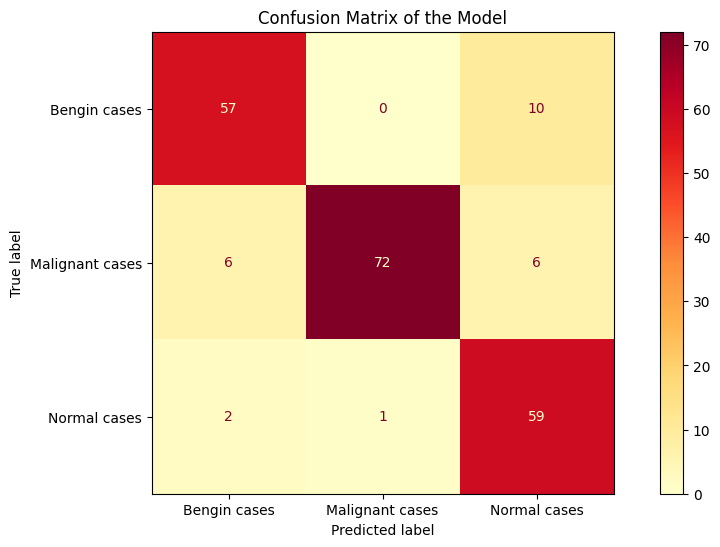

In [39]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Labels from the generator
class_labels = train_generator.class_indices.keys()
display_labels = class_labels

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.YlOrRd, ax=ax)

plt.title('Confusion Matrix of the Model')
plt.show()

In [40]:
allresults

[{'Model Name': 'MobileNetV2',
  'Accuracy': 0.8826291079812206,
  'Precision': 0.8832970378175857,
  'Recall': 0.8865006763417934,
  'F1 Score': 0.8807158948262672}]

### **VGG16 Model**

In [41]:
save_vgg16_model = 'models/vgg16_model.keras'

In [42]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten

In [43]:
vgg16_checkpoint = ModelCheckpoint(save_vgg16_model, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
vgg16_callbacks_list = [vgg16_checkpoint]

**Model Building**

In [44]:
vgg16_base_model = VGG16(weights='imagenet', include_top=False, input_shape=(image_dims[0], image_dims[1], 3))

# Freeze the convolutional base
vgg16_base_model.trainable = False

# Build your model
vgg16_model = Sequential([
    vgg16_base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [45]:
vgg16_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

**Training**

In [47]:
vgg16_history = vgg16_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=vgg16_callbacks_list)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.4609 - loss: 1.2131
Epoch 1: val_accuracy improved from None to 0.77209, saving model to models/vgg16_model.keras

Epoch 1: finished saving model to models/vgg16_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 46s 458ms/step - accuracy: 0.5327 - loss: 1.0397 - val_accuracy: 0.7721 - val_loss: 0.5843
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.7227 - loss: 0.6689
Epoch 2: val_accuracy did not improve from 0.77209
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 286ms/step - accuracy: 0.7477 - loss: 0.6283 - val_accuracy: 0.7395 - val_loss: 0.6629
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8249 - loss: 0.5410
Epoch 3: val_accuracy improved from 0.77209 to 0.81395, saving model to models/vgg16_model.keras

Epoch 3: finished saving model to models/vgg16_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 275ms/step - accuracy: 0.8151 - loss: 0.5227 - val_accuracy: 0.8140 - val_loss: 0.4420
Epoch 4/20
63/63 ━━━━━━━━━

**VGG16 Accuracy Plot**

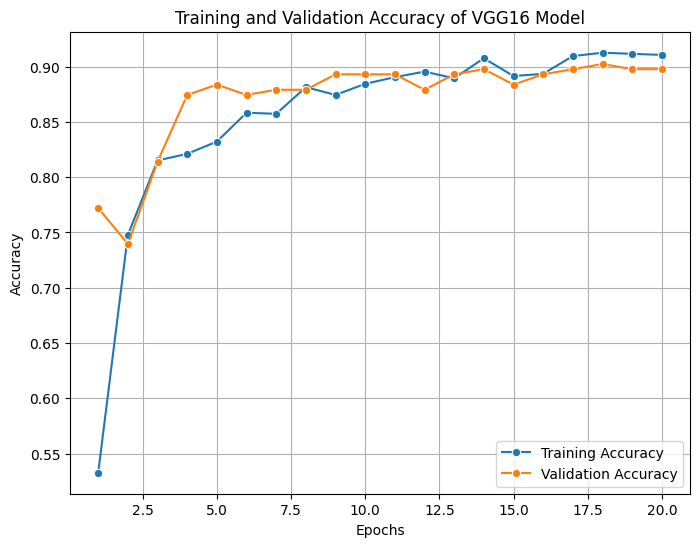

In [48]:
# Prepare DataFrame from Keras vgg16tory
vgg16_df = pd.DataFrame({
    "Epoch": range(1, len(vgg16_history.history['accuracy']) + 1),
    "Training Accuracy": vgg16_history.history['accuracy'],
    "Validation Accuracy": vgg16_history.history['val_accuracy']
})

# Melt DataFrame for Seaborn
vgg16_df_melted = vgg16_df.melt(id_vars="Epoch",
                   value_vars=["Training Accuracy", "Validation Accuracy"],
                   var_name="Type",
                   value_name="Accuracy")

plt.figure(figsize=(8,6))
sns.lineplot(data=vgg16_df_melted, x="Epoch", y="Accuracy", hue="Type", marker="o")
plt.title('Training and Validation Accuracy of VGG16 Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(title="")
plt.show()

**Confusion Matrix for VGG16**

In [49]:
# Predict on test set
vgg16_y_pred = vgg16_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
vgg16_y_pred_classes = np.argmax(vgg16_y_pred, axis=1)

# True labels
vgg16_y_true = test_generator.classes

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 425ms/step


Accuracy: 0.920
Precision: 0.928
Recall: 0.922
F1 Score: 0.918


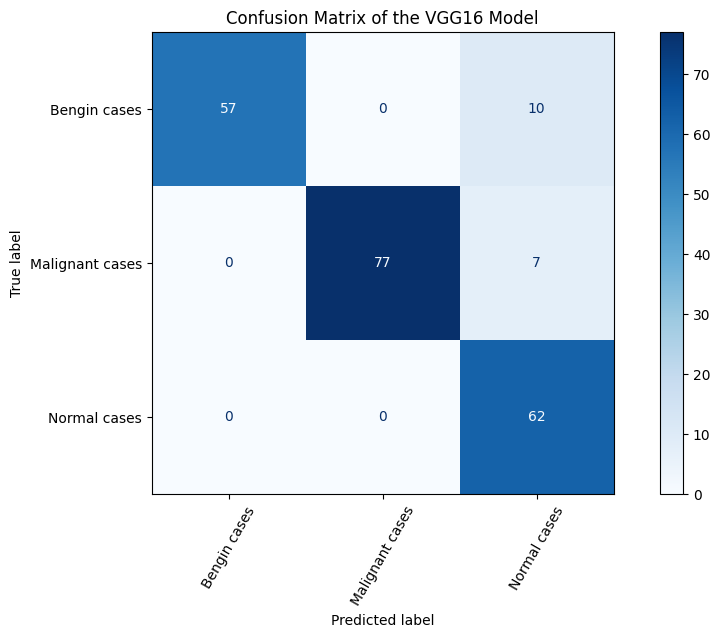

In [50]:
# Assuming y_true and y_pred_classes are defined
vgg16_cm = confusion_matrix(vgg16_y_true, vgg16_y_pred_classes)

# Calculate metrics (macro average for multiclass)
vgg16_accuracy = accuracy_score(vgg16_y_true, vgg16_y_pred_classes)
vgg16_precision = precision_score(vgg16_y_true, vgg16_y_pred_classes, average='macro')
vgg16_recall = recall_score(vgg16_y_true, vgg16_y_pred_classes, average='macro')
vgg16_f1 = f1_score(vgg16_y_true, vgg16_y_pred_classes, average='macro')

print(f'Accuracy: {vgg16_accuracy:.3f}')
print(f'Precision: {vgg16_precision:.3f}')
print(f'Recall: {vgg16_recall:.3f}')
print(f'F1 Score: {vgg16_f1:.3f}')

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=vgg16_cm, display_labels=train_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=60)
plt.title('Confusion Matrix of the VGG16 Model')
plt.show()

In [51]:
# Create a dictionary for the row
vgg16_results = {
    "Model Name": "VGG16",
    "Accuracy": vgg16_accuracy,
    "Precision": vgg16_precision,
    "Recall": vgg16_recall,
    "F1 Score": vgg16_f1
}

allresults.append(vgg16_results)

### **CNN Model**

In [52]:
save_cnn_model = 'models/cnn_model.keras'

In [53]:
cnn_cp = ModelCheckpoint(save_cnn_model, monitor='accuracy', save_best_only=True, mode='max')
cnn_callbacks_list = [cnn_cp]

**CNN Model Building**

In [54]:
from tensorflow.keras.layers import BatchNormalization, MaxPooling2D, Conv2D

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(image_dims[0], image_dims[1], 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(train_generator.num_classes, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
cnn_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

**Training**

In [56]:
cnn_history = cnn_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=cnn_callbacks_list)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 398ms/step - accuracy: 0.5196 - loss: 1.4528 - val_accuracy: 0.3953 - val_loss: 1.1784
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 242ms/step - accuracy: 0.6221 - loss: 1.0276 - val_accuracy: 0.3953 - val_loss: 1.9640
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 242ms/step - accuracy: 0.6623 - loss: 0.8764 - val_accuracy: 0.3953 - val_loss: 3.2837
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 242ms/step - accuracy: 0.6744 - loss: 0.7848 - val_accuracy: 0.3953 - val_loss: 5.9739
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.7136 - loss: 0.7225 - val_accuracy: 0.3953 - val_loss: 6.4649
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 237ms/step - accuracy: 0.7035 - loss: 0.7251 - val_accuracy: 0.4279 - val_loss: 6.7266
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.7417 - loss: 0.6701 - val_accuracy: 0.4326 - val_loss: 5.3756
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 242ms/step - accuracy: 0.7648 - loss: 0.5632 - val_accu

In [57]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_generator)
print(f"Test Accuracy: {cnn_test_accuracy * 100:.2f}%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - accuracy: 0.8685 - loss: 0.3588
Test Accuracy: 86.85%


**CNN Accuracy Plot**

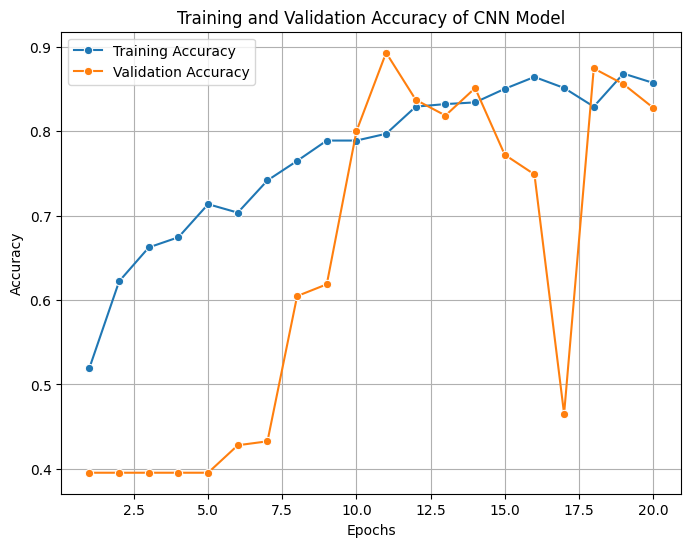

In [58]:
cnn_df = pd.DataFrame({
    "Epoch": range(1, len(cnn_history.history['accuracy']) + 1),
    "Training Accuracy": cnn_history.history['accuracy'],
    "Validation Accuracy": cnn_history.history['val_accuracy']
})

# Melt DataFrame for Seaborn
cnn_df_melted = cnn_df.melt(id_vars="Epoch",
                   value_vars=["Training Accuracy", "Validation Accuracy"],
                   var_name="Type",
                   value_name="Accuracy")

plt.figure(figsize=(8,6))
sns.lineplot(data=cnn_df_melted, x="Epoch", y="Accuracy", hue="Type", marker="o")
plt.title('Training and Validation Accuracy of CNN Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(title="")
plt.show()

**Confusion Matrix for CNN**

In [59]:
# Predict on test set
cnn_y_pred = cnn_model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1)
cnn_y_pred_classes = np.argmax(cnn_y_pred, axis=1)

# True labels
cnn_y_true = test_generator.classes

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step


Accuracy: 0.869
Precision: 0.882
Recall: 0.878
F1 Score: 0.869


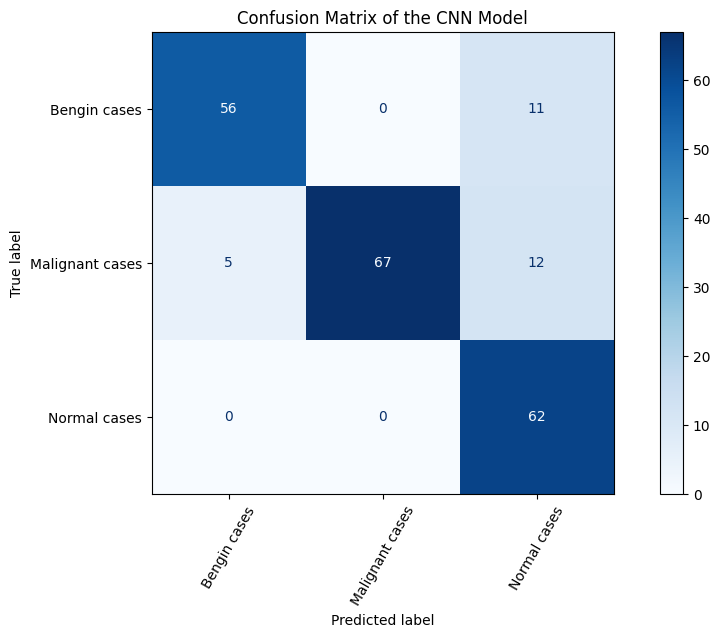

In [60]:
# Assuming y_true and y_pred_classes are defined
cnn_cm = confusion_matrix(cnn_y_true, cnn_y_pred_classes)

# Calculate metrics (macro average for multiclass)
cnn_accuracy = accuracy_score(cnn_y_true, cnn_y_pred_classes)
cnn_precision = precision_score(cnn_y_true, cnn_y_pred_classes, average='macro')
cnn_recall = recall_score(cnn_y_true, cnn_y_pred_classes, average='macro')
cnn_f1 = f1_score(cnn_y_true, cnn_y_pred_classes, average='macro')

print(f'Accuracy: {cnn_accuracy:.3f}')
print(f'Precision: {cnn_precision:.3f}')
print(f'Recall: {cnn_recall:.3f}')
print(f'F1 Score: {cnn_f1:.3f}')

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=train_generator.class_indices.keys())
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.xticks(rotation=60)
plt.title('Confusion Matrix of the CNN Model')
plt.show()

In [61]:
# Create a dictionary for the row
cnn_results = {
    "Model Name": "CNN",
    "Accuracy": cnn_accuracy,
    "Precision": cnn_precision,
    "Recall": cnn_recall,
    "F1 Score": cnn_f1
}

allresults.append(cnn_results)

### **Final Results**

In [62]:
results_df = pd.DataFrame(allresults)
results_df

,Model Name,Accuracy,Precision,Recall,F1 Score
0,MobileNetV2,0.882629,0.883297,0.886501,0.880716
1,VGG16,0.920188,0.928270,0.922471,0.918436
2,CNN,0.868545,0.882482,0.877813,0.868652


**Accuracy**

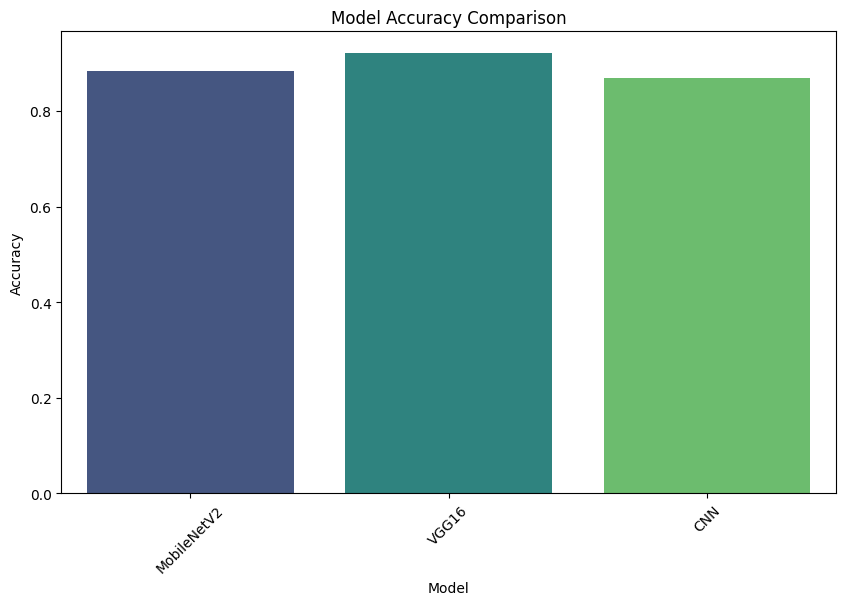

In [63]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='Accuracy', data=results_df, palette='viridis', hue='Model Name')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylabel('Accuracy')
plt.show()

**Precision**

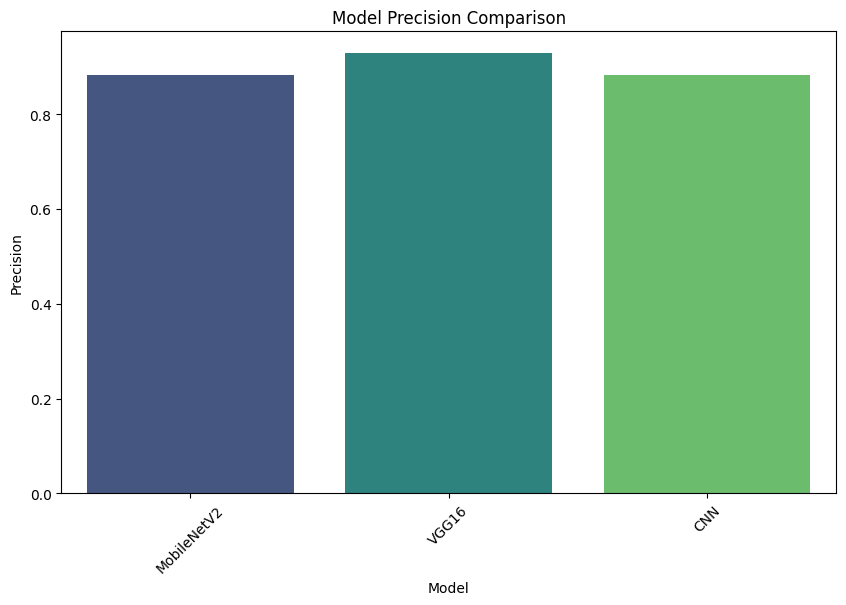

In [64]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='Precision', data=results_df, palette='viridis', hue='Model Name')
plt.title('Model Precision Comparison')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylabel('Precision')
plt.show()

**Recall**

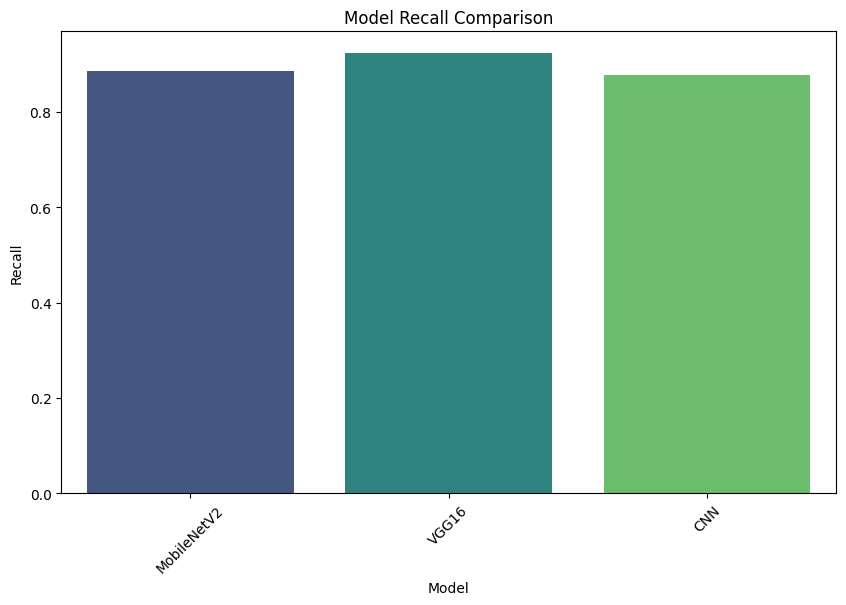

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='Recall', data=results_df, palette='viridis', hue='Model Name')
plt.title('Model Recall Comparison')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylabel('Recall')
plt.show()

**F1 Score**

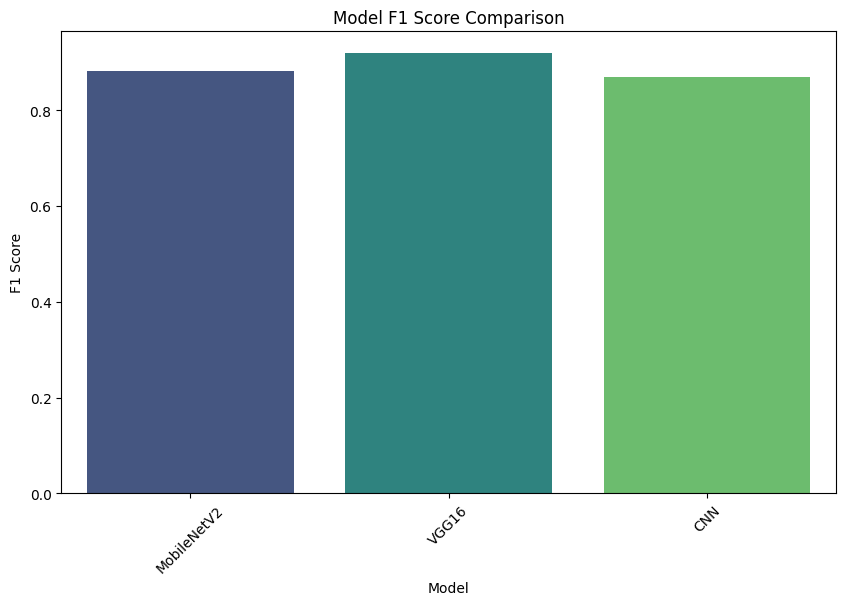

In [66]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model Name', y='F1 Score', data=results_df, palette='viridis', hue='Model Name')
plt.title('Model F1 Score Comparison')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylabel('F1 Score')
plt.show()

## **Test Predictions**

In [75]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

if 'results_df' not in globals():
    results_df = pd.DataFrame(allresults)

best_model_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model Name']

print(f"The best performing model is: {best_model_name} with Accuracy: {best_model_row['Accuracy']:.3f}")

The best performing model is: VGG16 with Accuracy: 0.920


In [76]:
if best_model_name == "MobileNetV2":
    try:
        best_model = load_model('models/mobilenet_model.keras')
        print("Loaded MobileNetV2 model.")
    except Exception as e:
        print(f"Error loading MobileNetV2 model: {e}. Using the in-memory object if available.")
        best_model = mobilenet_model
elif best_model_name == "VGG16":
    try:
        best_model = load_model('models/vgg16_model.keras')
        print("Loaded VGG16 model.")
    except Exception as e:
        print(f"Error loading VGG16 model: {e}. Using the in-memory object if available.")
        best_model = vgg16_model
elif best_model_name == "CNN":
    try:
        best_model = load_model('models/cnn_model.keras')
        print("Loaded CNN model.")
    except Exception as e:
        print(f"Error loading CNN model: {e}. Using the in-memory object if available.")
        best_model = cnn_model
else:
    print("Best model not found or recognized.")

    best_model = None

Loaded VGG16 model.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


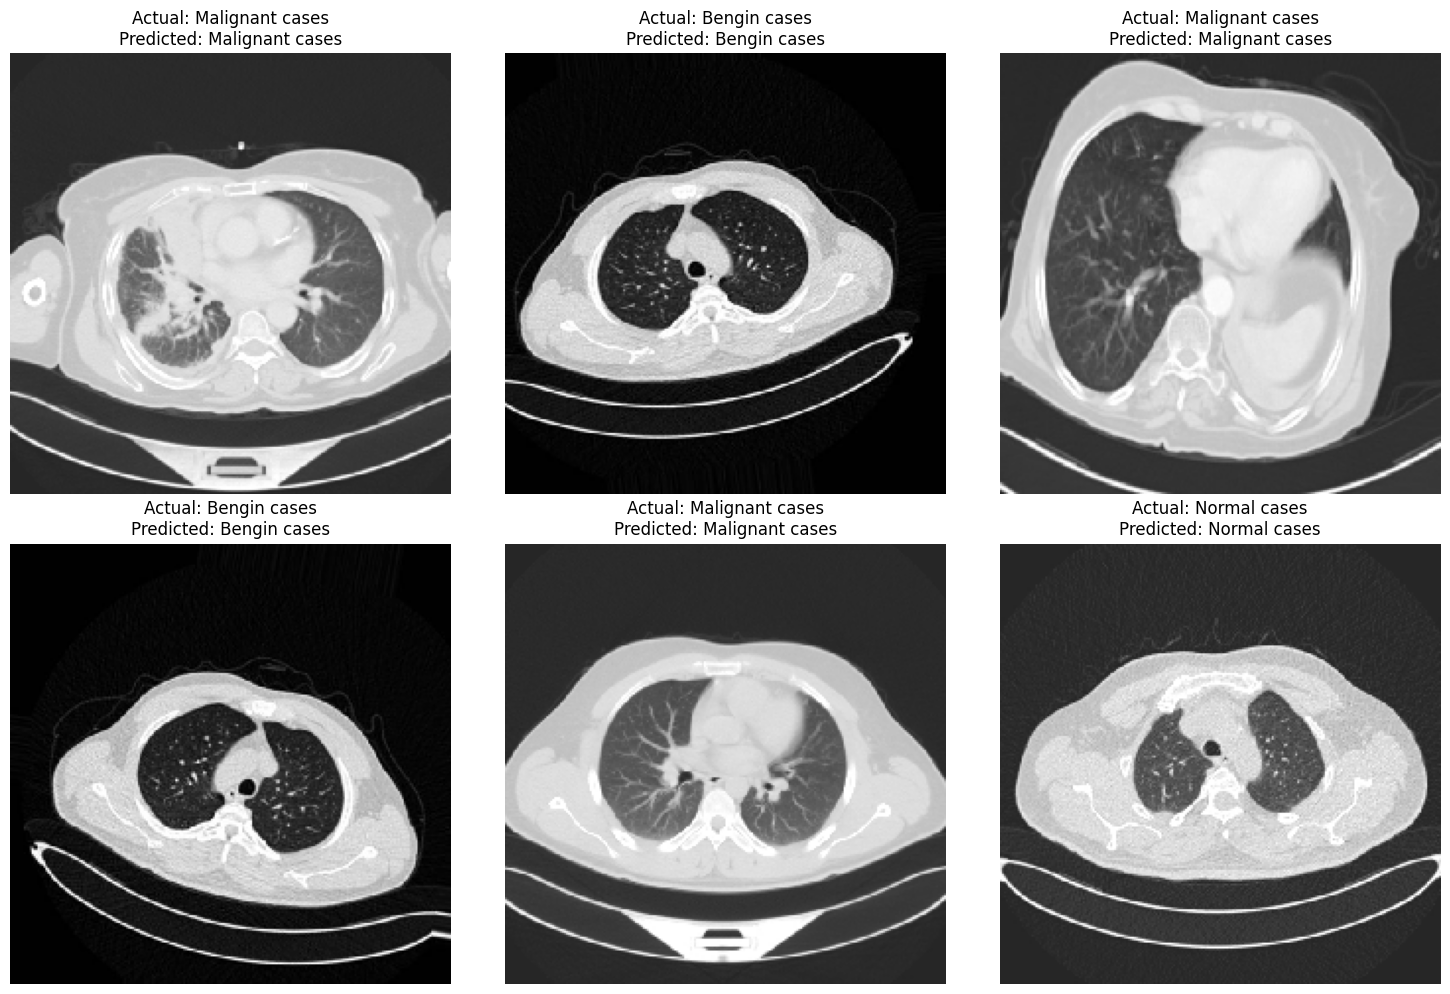

In [77]:
if best_model is None:
    print("Could not load any model. Cannot perform predictions.")
else:
    num_images_to_predict = 6
    all_test_images = []
    for class_folder in os.listdir(test_data_path):
        class_path = os.path.join(test_data_path, class_folder)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_test_images.append((os.path.join(class_path, img_name), class_folder))

    random.shuffle(all_test_images)
    selected_images = all_test_images[:num_images_to_predict]

    class_labels = {v: k for k, v in train_generator.class_indices.items()}

    plt.figure(figsize=(15, 10))
    for i, (img_path, actual_label) in enumerate(selected_images):
        img = load_img(img_path, target_size=image_dims)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        predictions = best_model.predict(img_array)
        predicted_class_idx = np.argmax(predictions, axis=1)[0]
        predicted_label = class_labels[predicted_class_idx]

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()